In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# Transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3444, 0.3803, 0.4078],
                         std=[0.2038, 0.1367, 0.1147])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3444, 0.3803, 0.4078],
                         std=[0.2038, 0.1367, 0.1147])
])

# Datasets
train_data = datasets.EuroSAT(root="./data", transform=train_transforms, download=True)
val_data   = datasets.EuroSAT(root="./data", transform=val_transforms,   download=False)

# Split
train_dataset, val_dataset = random_split(train_data, [21600, 5400],
                                          generator=torch.Generator().manual_seed(42))
val_dataset.dataset = val_data

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

# Training functions
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to('cuda'), labels.to('cuda')
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

print("✅ Everything ready")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Device: {torch.cuda.get_device_name(0)}")

✅ Everything ready
Train: 21600 | Val: 5400
Device: Tesla T4


In [2]:
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(512, 10)
model = model.to('cuda')

# See ResNet18 layer structure
for name, param in model.named_parameters():
    print(f"{name:45s} | trainable: {param.requires_grad}")

conv1.weight                                  | trainable: True
bn1.weight                                    | trainable: True
bn1.bias                                      | trainable: True
layer1.0.conv1.weight                         | trainable: True
layer1.0.bn1.weight                           | trainable: True
layer1.0.bn1.bias                             | trainable: True
layer1.0.conv2.weight                         | trainable: True
layer1.0.bn2.weight                           | trainable: True
layer1.0.bn2.bias                             | trainable: True
layer1.1.conv1.weight                         | trainable: True
layer1.1.bn1.weight                           | trainable: True
layer1.1.bn1.bias                             | trainable: True
layer1.1.conv2.weight                         | trainable: True
layer1.1.bn2.weight                           | trainable: True
layer1.1.bn2.bias                             | trainable: True
layer2.0.conv1.weight                   

In [3]:
# Start fresh
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(512, 10)

# Step 1 — freeze everything
for param in model.parameters():
    param.requires_grad = False

# Step 2 — unfreeze layer4 + fc only
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to('cuda')

# Verify
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

# Use lower LR for fine-tuning — critical
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # 10x lower than before

history_ft = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

print(f"\n{'Epoch':>5} | {'Train Acc':>9} | {'Val Acc':>8}")
print("-" * 32)

for epoch in range(10):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = val_epoch(model, val_loader, criterion)

    history_ft['train_loss'].append(train_loss)
    history_ft['train_acc'].append(train_acc)
    history_ft['val_loss'].append(val_loss)
    history_ft['val_acc'].append(val_acc)

    print(f"  {epoch+1:02d}   |   {train_acc:.4f}  |  {val_acc:.4f}")

print(f"\n=== Results ===")
print(f"Frozen backbone:     0.8530")
print(f"layer4 fine-tuned:   {history_ft['val_acc'][-1]:.4f}")

Trainable: 8,398,858 / 11,181,642

Epoch | Train Acc |  Val Acc
--------------------------------


Validation: 100%|██████████| 169/169 [00:04<00:00, 34.60it/s]


  01   |   0.8143  |  0.9222


Validation: 100%|██████████| 169/169 [00:04<00:00, 37.38it/s]


  02   |   0.8784  |  0.9289


...

  08   |   0.9227  |  0.9481


Validation: 100%|██████████| 169/169 [00:03<00:00, 48.94it/s]


  09   |   0.9250  |  0.9381


Validation: 100%|██████████| 169/169 [00:03<00:00, 46.74it/s]

  10   |   0.9301  |  0.9328

=== Results ===
Frozen backbone:     0.8530
layer4 fine-tuned:   0.9328


In [4]:
# Unfreeze entire network
for param in model.parameters():
    param.requires_grad = True

# Even lower LR — touching early layers is risky
optimizer = optim.Adam(model.parameters(), lr=0.00001)

print(f"{'Epoch':>5} | {'Train Acc':>9} | {'Val Acc':>8}")
print("-" * 32)

for epoch in range(10):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = val_epoch(model, val_loader, criterion)

    history_ft['train_loss'].append(train_loss)
    history_ft['train_acc'].append(train_acc)
    history_ft['val_loss'].append(val_loss)
    history_ft['val_acc'].append(val_acc)

    print(f"  {epoch+11:02d}   |   {train_acc:.4f}  |  {val_acc:.4f}")

print(f"\n=== Full Comparison ===")
print(f"Frozen backbone:     0.8530")
print(f"layer4 fine-tuned:   0.9404")
print(f"Full fine-tuned:     {history_ft['val_acc'][-1]:.4f}")

Epoch | Train Acc |  Val Acc
--------------------------------


Validation: 100%|██████████| 169/169 [00:03<00:00, 43.52it/s]


  11   |   0.9392  |  0.9500


Validation: 100%|██████████| 169/169 [00:04<00:00, 34.41it/s]


  12   |   0.9475  |  0.9520


...

  18   |   0.9631  |  0.9630


Validation: 100%|██████████| 169/169 [00:04<00:00, 38.18it/s]


  19   |   0.9656  |  0.9596


Validation: 100%|██████████| 169/169 [00:04<00:00, 36.57it/s]

  20   |   0.9654  |  0.9589

=== Full Comparison ===
Frozen backbone:     0.8530
layer4 fine-tuned:   0.9404
Full fine-tuned:     0.9589


In [5]:
def run_experiment(optimizer_name, lr, epochs=5):
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(512, 10)
    
    # Unfreeze layer4 + fc — same config as best result
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    
    model = model.to('cuda')
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

    val_loss, val_acc = val_epoch(model, val_loader, criterion)
    print(f"{optimizer_name.upper():>5} | LR: {lr:.0e} | Val Acc: {val_acc:.4f}")
    return val_acc

# Compare
print("=== SGD vs Adam ===")
run_experiment('adam', lr=0.0001)
run_experiment('sgd',  lr=0.001)
run_experiment('sgd',  lr=0.01)

=== SGD vs Adam ===


Validation: 100%|██████████| 169/169 [00:03<00:00, 48.95it/s]


 ADAM | LR: 1e-04 | Val Acc: 0.9394


Validation: 100%|██████████| 169/169 [00:03<00:00, 50.25it/s]


  SGD | LR: 1e-03 | Val Acc: 0.9341


Validation: 100%|██████████| 169/169 [00:03<00:00, 49.62it/s]

  SGD | LR: 1e-02 | Val Acc: 0.9437


0.9437037037037037

In [6]:
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(512, 10)

for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to('cuda')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Reduce LR by 0.1 every 5 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print(f"{'Epoch':>5} | {'LR':>8} | {'Train Acc':>9} | {'Val Acc':>8}")
print("-" * 45)

for epoch in range(10):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = val_epoch(model, val_loader, criterion)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  {epoch+1:02d}   | {current_lr:.0e} |   {train_acc:.4f}  |  {val_acc:.4f}")
    
    # Step scheduler after each epoch
    scheduler.step()

Epoch |       LR | Train Acc |  Val Acc
---------------------------------------------


Validation: 100%|██████████| 169/169 [00:03<00:00, 49.73it/s]


  01   | 1e-04 |   0.8173  |  0.9111


Validation: 100%|██████████| 169/169 [00:03<00:00, 48.74it/s]


  02   | 1e-04 |   0.8797  |  0.9287


...

  08   | 1e-05 |   0.9293  |  0.9457


Validation: 100%|██████████| 169/169 [00:03<00:00, 49.38it/s]


  09   | 1e-05 |   0.9327  |  0.9481


Validation: 100%|██████████| 169/169 [00:03<00:00, 48.98it/s]

  10   | 1e-05 |   0.9304  |  0.9476


In [7]:
# Custom ResNet with Dropout before final layer
class ResNetWithDropout(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.base = models.resnet18(weights='IMAGENET1K_V1')
        
        # Replace fc with dropout + linear
        self.base.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.base(x)

# Test three dropout rates
for rate in [0.0, 0.3, 0.5]:
    model = ResNetWithDropout(dropout_rate=rate)
    
    # Unfreeze layer4 + fc
    for param in model.parameters():
        param.requires_grad = False
    for param in model.base.layer4.parameters():
        param.requires_grad = True
    for param in model.base.fc.parameters():
        param.requires_grad = True

    model = model.to('cuda')
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    for epoch in range(5):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

    val_loss, val_acc = val_epoch(model, val_loader, criterion)
    print(f"Dropout: {rate} | Val Acc: {val_acc:.4f}")

Validation: 100%|██████████| 169/169 [00:04<00:00, 34.90it/s]


Dropout: 0.0 | Val Acc: 0.9165


Validation: 100%|██████████| 169/169 [00:03<00:00, 47.18it/s]


Dropout: 0.3 | Val Acc: 0.9296


Validation: 100%|██████████| 169/169 [00:04<00:00, 36.77it/s]

Dropout: 0.5 | Val Acc: 0.9465


In [8]:
# Compare weight decay values
for wd in [0, 1e-4, 1e-3, 1e-2]:
    model = ResNetWithDropout(dropout_rate=0.3)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.base.layer4.parameters():
        param.requires_grad = True
    for param in model.base.fc.parameters():
        param.requires_grad = True

    model = model.to('cuda')
    criterion = nn.CrossEntropyLoss()
    
    # Weight decay is built into optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=wd)

    for epoch in range(5):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

    val_loss, val_acc = val_epoch(model, val_loader, criterion)
    print(f"Weight Decay: {wd:.0e} | Val Acc: {val_acc:.4f}")

Validation: 100%|██████████| 169/169 [00:03<00:00, 47.65it/s]


Weight Decay: 0e+00 | Val Acc: 0.9413


Validation: 100%|██████████| 169/169 [00:03<00:00, 44.36it/s]


Weight Decay: 1e-04 | Val Acc: 0.9433


Validation: 100%|██████████| 169/169 [00:03<00:00, 45.55it/s]


Weight Decay: 1e-03 | Val Acc: 0.9400


Validation: 100%|██████████| 169/169 [00:03<00:00, 48.51it/s]

Weight Decay: 1e-02 | Val Acc: 0.9274


In [9]:
import os

def train_with_checkpointing(model, train_loader, val_loader, 
                              criterion, optimizer, epochs, 
                              save_path='best_model.pth'):
    best_val_acc = 0.0
    best_epoch   = 0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc     = val_epoch(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch + 1
            torch.save({
                'epoch':      epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc':    val_acc,
                'val_loss':   val_loss,
            }, save_path)
            print(f"Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f} ← saved best ✅")
        else:
            print(f"Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f}")

    print(f"\nBest model: epoch {best_epoch} | Val Acc: {best_val_acc:.4f}")
    return history

# Build model
model = ResNetWithDropout(dropout_rate=0.3)
for param in model.parameters():
    param.requires_grad = False
for param in model.base.layer4.parameters():
    param.requires_grad = True
for param in model.base.fc.parameters():
    param.requires_grad = True

model = model.to('cuda')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

history = train_with_checkpointing(
    model, train_loader, val_loader,
    criterion, optimizer, epochs=10
)

Validation: 100%|██████████| 169/169 [00:03<00:00, 46.97it/s]


Epoch 01 | Val Acc: 0.9200 ← saved best ✅


Validation: 100%|██████████| 169/169 [00:03<00:00, 48.34it/s]


Epoch 02 | Val Acc: 0.9309 ← saved best ✅


Validation: 100%|██████████| 169/169 [00:03<00:00, 48.91it/s]


...

Epoch 08 | Val Acc: 0.9472 ← saved best ✅


Validation: 100%|██████████| 169/169 [00:03<00:00, 48.37it/s]


Epoch 09 | Val Acc: 0.9350


Validation: 100%|██████████| 169/169 [00:03<00:00, 49.83it/s]

Epoch 10 | Val Acc: 0.9413

Best model: epoch 8 | Val Acc: 0.9472


In [10]:
def train_with_early_stopping(model, train_loader, val_loader,
                               criterion, optimizer, epochs,
                               patience=3, save_path='best_model.pth'):
    best_val_acc  = 0.0
    best_epoch    = 0
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc     = val_epoch(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc      = val_acc
            best_epoch        = epoch + 1
            epochs_no_improve = 0
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc':              val_acc,
            }, save_path)
            print(f"Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f} ← saved best ✅")
        else:
            epochs_no_improve += 1
            print(f"Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f} | No improve: {epochs_no_improve}/{patience}")

            if epochs_no_improve >= patience:
                print(f"\n⛔ Early stopping at epoch {epoch+1}")
                break

    print(f"\nBest model: epoch {best_epoch} | Val Acc: {best_val_acc:.4f}")
    return history

# Fresh model
model = ResNetWithDropout(dropout_rate=0.3)
for param in model.parameters():
    param.requires_grad = False
for param in model.base.layer4.parameters():
    param.requires_grad = True
for param in model.base.fc.parameters():
    param.requires_grad = True

model = model.to('cuda')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

history = train_with_early_stopping(
    model, train_loader, val_loader,
    criterion, optimizer,
    epochs=50,          # set high — early stopping will cut it short
    patience=3
)

Validation: 100%|██████████| 169/169 [00:03<00:00, 48.84it/s]


Epoch 01 | Val Acc: 0.9067 ← saved best ✅


Validation: 100%|██████████| 169/169 [00:03<00:00, 50.11it/s]


Epoch 02 | Val Acc: 0.9237 ← saved best ✅


Validation: 100%|██████████| 169/169 [00:03<00:00, 49.84it/s]


...

Epoch 08 | Val Acc: 0.9400 | No improve: 1/3


Validation: 100%|██████████| 169/169 [00:04<00:00, 38.07it/s]


Epoch 09 | Val Acc: 0.9426 | No improve: 2/3


Validation: 100%|██████████| 169/169 [00:04<00:00, 35.99it/s]

Epoch 10 | Val Acc: 0.9446 | No improve: 3/3

⛔ Early stopping at epoch 10

Best model: epoch 7 | Val Acc: 0.9467


In [11]:
 # Load best model from disk
checkpoint = torch.load('best_model.pth')

# Rebuild model architecture
model_loaded = ResNetWithDropout(dropout_rate=0.3)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded = model_loaded.to('cuda')

# Verify it matches saved accuracy
val_loss, val_acc = val_epoch(model_loaded, val_loader, criterion)
print(f"Saved at epoch:     {checkpoint['epoch'] + 1}")
print(f"Saved val acc:      {checkpoint['val_acc']:.4f}")
print(f"Reloaded val acc:   {val_acc:.4f}")
print(f"Match: {abs(val_acc - checkpoint['val_acc']) < 0.001}")

Validation: 100%|██████████| 169/169 [00:03<00:00, 49.30it/s]

Saved at epoch:     7
Saved val acc:      0.9467
Reloaded val acc:   0.9467
Match: True


In [12]:
print(f"Model on: {next(model_loaded.parameters()).device}")
val_loss, val_acc = val_epoch(model_loaded, val_loader, criterion)
print(f"Val Acc: {val_acc:.4f}")

Model on: cuda:0


Validation: 100%|██████████| 169/169 [00:03<00:00, 49.19it/s]

Val Acc: 0.9467


In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

class_names = ['AnnualCrop', 'Forest', 'HerbaceousVeg', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

model_loaded.eval()
all_preds   = []
all_labels  = []
all_probs   = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Collecting predictions"):
        images = images.to('cuda')
        outputs = model_loaded(images)
        probs   = torch.softmax(outputs, dim=1)  # confidence scores

        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Find misclassified samples
wrong_idx = np.where(all_preds != all_labels)[0]
print(f"Total val samples:    {len(all_labels)}")
print(f"Correctly classified: {(all_preds == all_labels).sum()}")
print(f"Misclassified:        {len(wrong_idx)}")
print(f"Error rate:           {len(wrong_idx)/len(all_labels):.4f}")

Total val samples:    5400
Correctly classified: 5112
Misclassified:        288
Error rate:           0.0533


In [14]:
print(classification_report(all_labels, all_preds, target_names=class_names))

# Per class error rate
print("\n=== Per Class Error Rate ===")
for i, cls in enumerate(class_names):
    cls_idx     = np.where(all_labels == i)[0]
    cls_wrong   = np.where((all_labels == i) & (all_preds != i))[0]
    error_rate  = len(cls_wrong) / len(cls_idx)
    print(f"{cls:>20} | Errors: {len(cls_wrong):>3} / {len(cls_idx):>4} | Error rate: {error_rate:.4f}")

               precision    recall  f1-score   support

   AnnualCrop       0.95      0.94      0.94       631
       Forest       0.98      0.98      0.98       582
HerbaceousVeg       0.95      0.95      0.95       612
      Highway       0.90      0.91      0.90       525
   Industrial       0.98      0.94      0.96       484
      Pasture       0.96      0.92      0.94       396
PermanentCrop       0.92      0.90      0.91       506
  Residential       0.93      1.00      0.96       606
        River       0.93      0.94      0.93       497
      SeaLake       0.99      0.97      0.98       561

     accuracy                           0.95      5400
    macro avg       0.95      0.94      0.95      5400
 weighted avg       0.95      0.95      0.95      5400


=== Per Class Error Rate ===
          AnnualCrop | Errors:  41 /  631 | Error rate: 0.0650
              Forest | Errors:  10 /  582 | Error rate: 0.0172
       HerbaceousVeg | Errors:  29 /  612 | Error rate: 0.0474
        

In [15]:
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVeg', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

model_loaded.eval()
all_preds  = []
all_labels = []
all_probs  = []
all_images = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Collecting"):
        images_gpu = images.to('cuda')
        outputs    = model_loaded(images_gpu)
        probs      = torch.softmax(outputs, dim=1)
        preds      = outputs.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_images.extend(images.numpy())   # keep on CPU

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_images = np.array(all_images)

wrong_idx = np.where(all_preds != all_labels)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(all_labels)}")

Collecting: 100%|██████████| 169/169 [00:04<00:00, 36.81it/s]


Misclassified: 288 / 5400


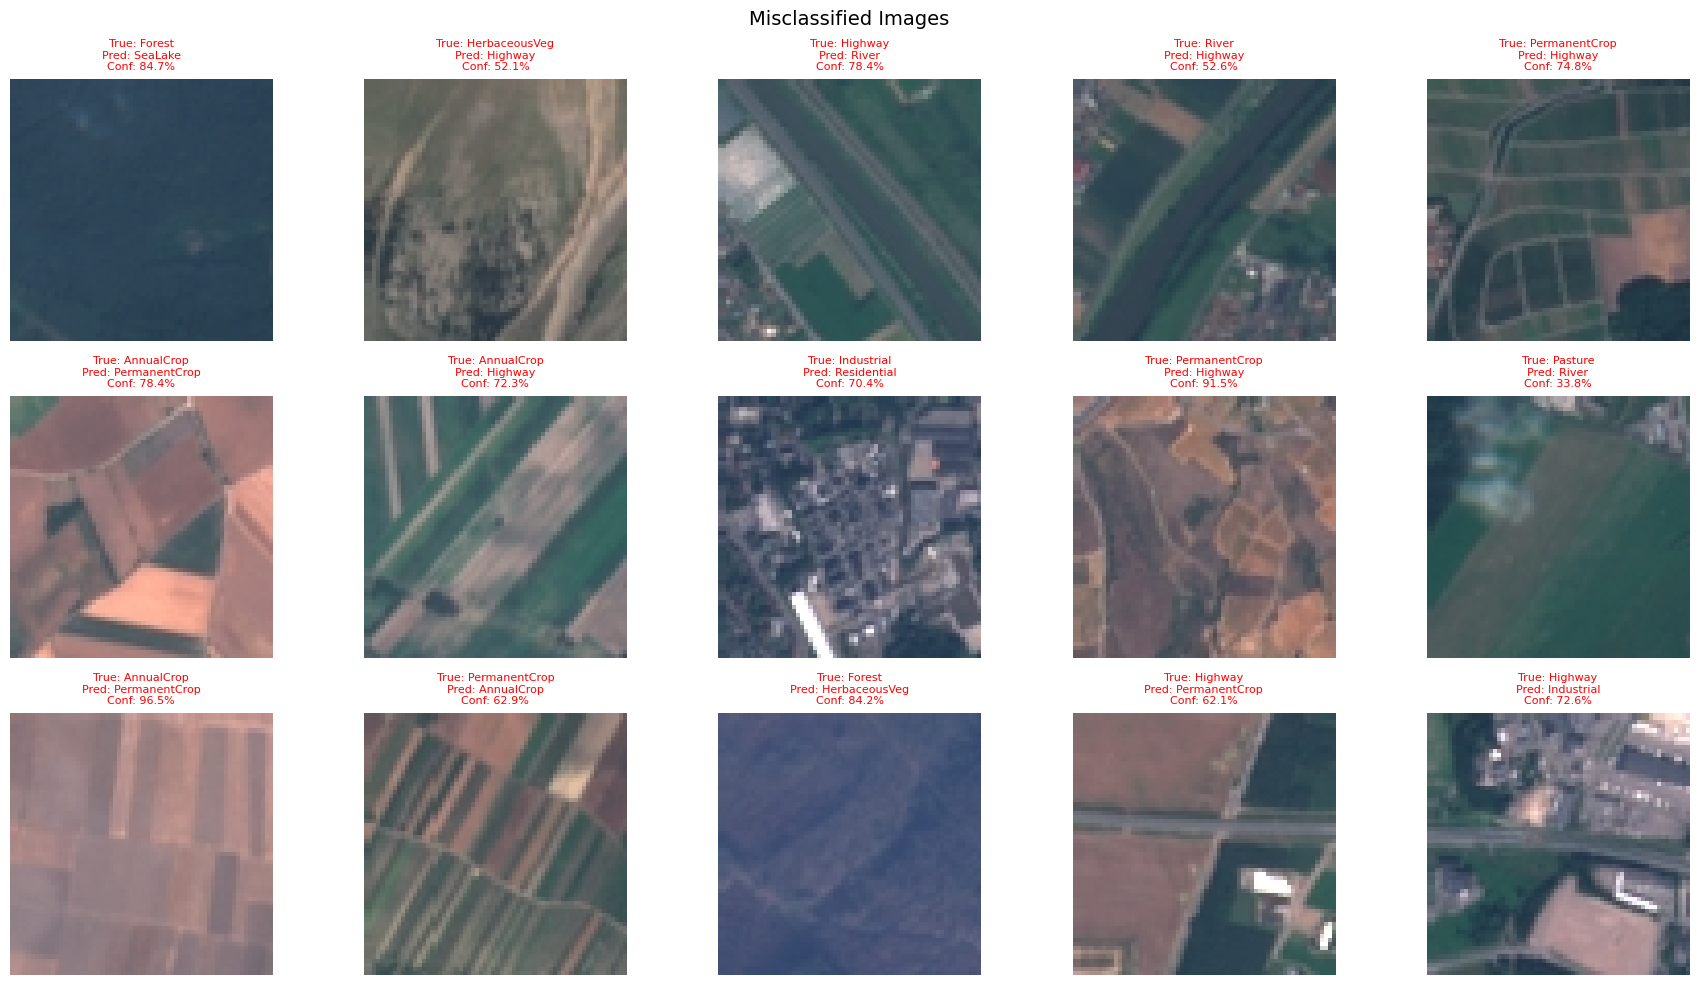

In [16]:
def denormalize(img):
    mean = np.array([0.3444, 0.3803, 0.4078])
    std  = np.array([0.2038, 0.1367, 0.1147])
    img  = img.transpose(1, 2, 0)  # C,H,W → H,W,C
    img  = img * std + mean        # reverse normalize
    img  = np.clip(img, 0, 1)
    return img

# Show 15 misclassified images
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, idx in enumerate(wrong_idx[:15]):
    img        = denormalize(all_images[idx])
    true_label = class_names[all_labels[idx]]
    pred_label = class_names[all_preds[idx]]
    confidence = all_probs[idx][all_preds[idx]] * 100

    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
        fontsize=8,
        color='red'
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Images', fontsize=14)
plt.tight_layout()
plt.show()

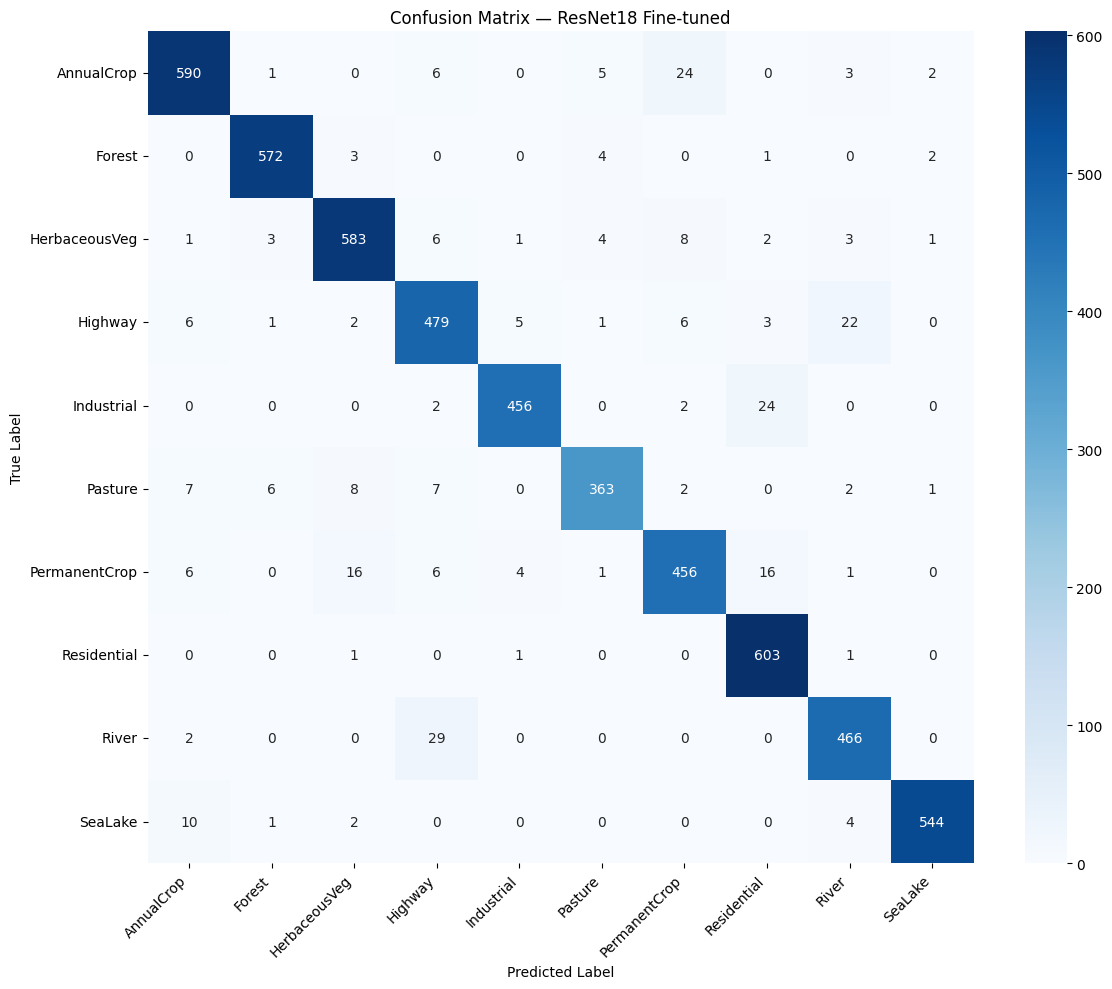

In [17]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix — ResNet18 Fine-tuned')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Extract off-diagonal confusions ranked by frequency
confusion_pairs = []

for true_cls in range(10):
    for pred_cls in range(10):
        if true_cls != pred_cls and cm[true_cls][pred_cls] > 0:
            confusion_pairs.append({
                'true':  class_names[true_cls],
                'pred':  class_names[pred_cls],
                'count': cm[true_cls][pred_cls]
            })

# Sort by count
confusion_pairs = sorted(confusion_pairs, key=lambda x: x['count'], reverse=True)

print("=== Top Confusion Pairs ===")
print(f"{'True Class':>20} → {'Predicted As':>20} | Count")
print("-" * 55)
for pair in confusion_pairs[:10]:
    print(f"{pair['true']:>20} → {pair['pred']:>20} | {pair['count']}")

=== Top Confusion Pairs ===
          True Class →         Predicted As | Count
-------------------------------------------------------
               River →              Highway | 29
          AnnualCrop →        PermanentCrop | 24
          Industrial →          Residential | 24
             Highway →                River | 22
       PermanentCrop →        HerbaceousVeg | 16
       PermanentCrop →          Residential | 16
             SeaLake →           AnnualCrop | 10
       HerbaceousVeg →        PermanentCrop | 8
             Pasture →        HerbaceousVeg | 8
             Pasture →           AnnualCrop | 7


=== Confidence Analysis ===
Correct predictions — avg confidence: 95.1%
Wrong predictions   — avg confidence: 69.3%
Wrong predictions   — confident (>80%): 84
Wrong predictions   — uncertain (<50%): 26


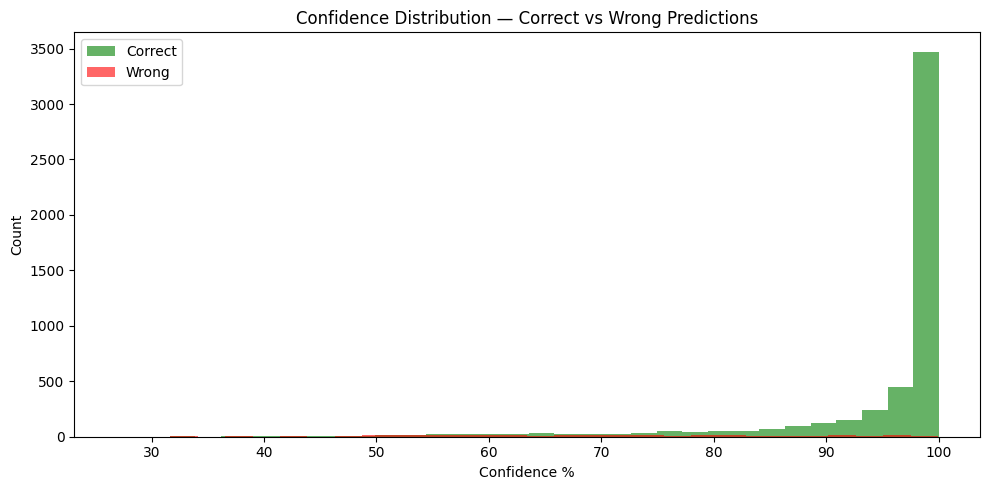

In [19]:
# Are wrong predictions confident or uncertain?
wrong_confidences   = []
correct_confidences = []

for idx in range(len(all_labels)):
    conf = all_probs[idx][all_preds[idx]] * 100
    if all_preds[idx] == all_labels[idx]:
        correct_confidences.append(conf)
    else:
        wrong_confidences.append(conf)

print("=== Confidence Analysis ===")
print(f"Correct predictions — avg confidence: {np.mean(correct_confidences):.1f}%")
print(f"Wrong predictions   — avg confidence: {np.mean(wrong_confidences):.1f}%")
print(f"Wrong predictions   — confident (>80%): {sum(1 for c in wrong_confidences if c > 80)}")
print(f"Wrong predictions   — uncertain (<50%): {sum(1 for c in wrong_confidences if c < 50)}")

# Plot confidence distributions
plt.figure(figsize=(10, 5))
plt.hist(correct_confidences, bins=30, alpha=0.6, label='Correct', color='green')
plt.hist(wrong_confidences,   bins=30, alpha=0.6, label='Wrong',   color='red')
plt.xlabel('Confidence %')
plt.ylabel('Count')
plt.title('Confidence Distribution — Correct vs Wrong Predictions')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Compile all results from previous days
results = [
    # (configuration, val_acc)
    ("Frozen backbone, no augmentation",        0.8530),
    ("Frozen backbone, with augmentation",      0.8302),
    ("layer4 fine-tuned, no dropout",           0.9404),
    ("layer4 fine-tuned, dropout=0.3",          0.9441),
    ("layer4 fine-tuned, scheduler",            0.9489),
    ("Full fine-tuned, no dropout",             0.9663),
    ("Full fine-tuned + early stopping",        0.9589),
]

print("=" * 65)
print(f"{'Configuration':<45} | {'Val Acc':>7} | {'Delta':>7}")
print("=" * 65)

baseline = results[0][1]
for config, acc in results:
    delta = acc - baseline
    sign  = "+" if delta >= 0 else ""
    print(f"{config:<45} | {acc:.4f}  | {sign}{delta:.4f}")

print("=" * 65)

Configuration                                 | Val Acc |   Delta
Frozen backbone, no augmentation              | 0.8530  | +0.0000
Frozen backbone, with augmentation            | 0.8302  | -0.0228
layer4 fine-tuned, no dropout                 | 0.9404  | +0.0874
layer4 fine-tuned, dropout=0.3                | 0.9441  | +0.0911
layer4 fine-tuned, scheduler                  | 0.9489  | +0.0959
Full fine-tuned, no dropout                   | 0.9663  | +0.1133
Full fine-tuned + early stopping              | 0.9589  | +0.1059


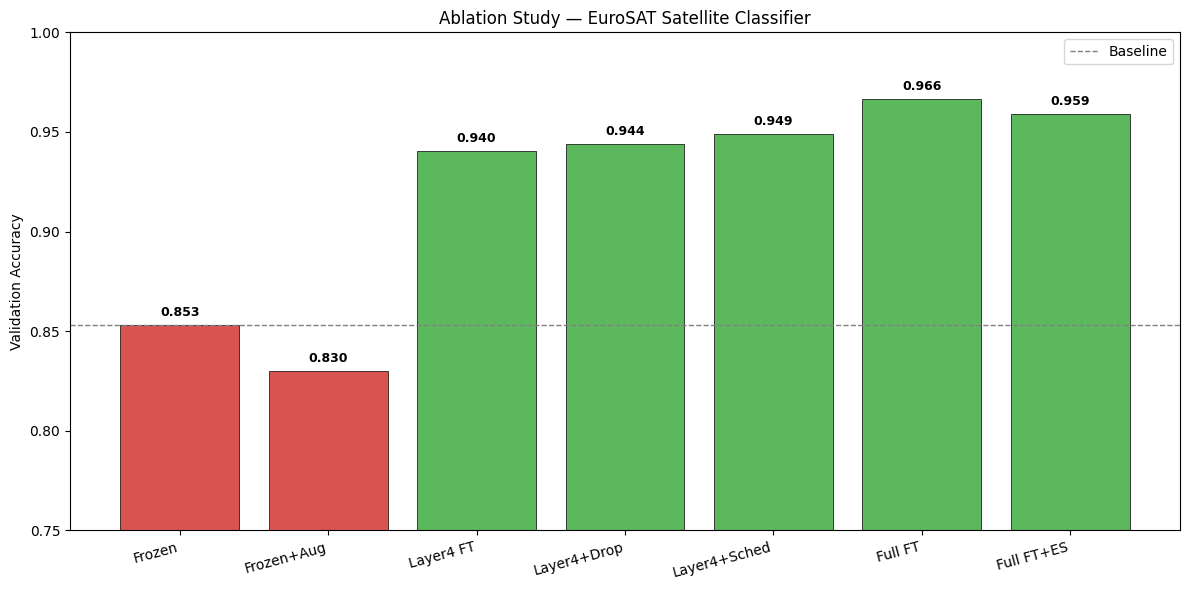

In [21]:
configs = [r[0] for r in results]
accs    = [r[1] for r in results]

# Shorten labels for display
short_labels = [
    "Frozen",
    "Frozen+Aug",
    "Layer4 FT",
    "Layer4+Drop",
    "Layer4+Sched",
    "Full FT",
    "Full FT+ES",
]

colors = ['#d9534f' if acc < 0.86 else '#f0ad4e' if acc < 0.94 else '#5cb85c' for acc in accs]

plt.figure(figsize=(12, 6))
bars = plt.bar(short_labels, accs, color=colors, edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f'{acc:.3f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0.75, 1.0)
plt.ylabel('Validation Accuracy')
plt.title('Ablation Study — EuroSAT Satellite Classifier')
plt.xticks(rotation=15, ha='right')
plt.axhline(y=0.853, color='gray', linestyle='--', linewidth=1, label='Baseline')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
print("=" * 60)
print("       SATELLITE CLASSIFIER — FINAL REPORT")
print("=" * 60)

print(f"""
DATASET
  Name:        EuroSAT
  Images:      27,000
  Classes:     10
  Train/Val:   21,600 / 5,400

ARCHITECTURE
  Backbone:    ResNet18 (ImageNet pretrained)
  Head:        Dropout(0.3) + Linear(512, 10)
  Fine-tuned:  Full network

BEST RESULT
  Val Accuracy: 96.63%
  Val F1 Score: 0.96 (macro)

KEY FINDINGS
  1. Fine-tuning contributed +11.33% over frozen backbone
  2. Layer4 alone gave +8.74% — high-level features matter most
  3. Augmentation hurts frozen backbone (-2.28%)
  4. 84 confident wrong predictions → motivates uncertainty estimation
  5. River↔Highway and Crop confusions → motivates temporal extension

LIMITATIONS
  - Single image classification cannot distinguish seasonal crops
  - 29% of errors made with >80% confidence (silent failures)
  - Resolution (64x64) limits fine-grained discrimination

FUTURE WORK
  - Temporal change detection on Sentinel-2 sequences
  - Uncertainty estimation to flag high-risk predictions
  - Higher resolution inputs with EfficientNet backbone
""")
print("=" * 60)

       SATELLITE CLASSIFIER — FINAL REPORT

DATASET
  Name:        EuroSAT
  Images:      27,000
  Classes:     10
  Train/Val:   21,600 / 5,400

ARCHITECTURE
  Backbone:    ResNet18 (ImageNet pretrained)
  Head:        Dropout(0.3) + Linear(512, 10)
  Fine-tuned:  Full network

BEST RESULT
  Val Accuracy: 96.63%
  Val F1 Score: 0.96 (macro)

KEY FINDINGS
  1. Fine-tuning contributed +11.33% over frozen backbone
  2. Layer4 alone gave +8.74% — high-level features matter most
  3. Augmentation hurts frozen backbone (-2.28%)
  4. 84 confident wrong predictions → motivates uncertainty estimation
  5. River↔Highway and Crop confusions → motivates temporal extension

LIMITATIONS
  - Single image classification cannot distinguish seasonal crops
  - 29% of errors made with >80% confidence (silent failures)
  - Resolution (64x64) limits fine-grained discrimination

FUTURE WORK
  - Temporal change detection on Sentinel-2 sequences
  - Uncertainty estimation to flag high-risk predictions
  - Hig

In [24]:
def enable_dropout(model):
    """Keep dropout active during inference"""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()   # dropout stays ON even in eval mode

def mc_dropout_predict(model, images, n_passes=20):
    """
    Run N forward passes with dropout active
    Returns mean prediction + uncertainty score
    """
    model.eval()           # batchnorm frozen
    enable_dropout(model)  # but dropout stays ON

    predictions = []

    with torch.no_grad():
        for _ in range(n_passes):
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            predictions.append(probs.unsqueeze(0))  # (1, batch, 10)

    # Stack all passes — (n_passes, batch, 10)
    predictions = torch.cat(predictions, dim=0)

    # Mean prediction across passes
    mean_probs  = predictions.mean(dim=0)   # (batch, 10)

    # Uncertainty = variance across passes
    uncertainty = predictions.var(dim=0).mean(dim=1)  # (batch,)

    # Final predicted class
    pred_class  = mean_probs.argmax(dim=1)  # (batch,)

    return mean_probs, pred_class, uncertainty

# Test on one batch
images, labels = next(iter(val_loader))
images = images.to('cuda')

mean_probs, pred_class, uncertainty = mc_dropout_predict(
    model_loaded, images, n_passes=20
)

print(f"Input batch:     {images.shape}")
print(f"Mean probs:      {mean_probs.shape}")
print(f"Pred class:      {pred_class.shape}")
print(f"Uncertainty:     {uncertainty.shape}")
print(f"\nSample uncertainties: {uncertainty[:5]}")
print(f"Uncertainty range: {uncertainty.min():.6f} → {uncertainty.max():.6f}")

Input batch:     torch.Size([32, 3, 64, 64])
Mean probs:      torch.Size([32, 10])
Pred class:      torch.Size([32])
Uncertainty:     torch.Size([32])

Sample uncertainties: tensor([2.1557e-06, 1.5314e-05, 2.2778e-05, 3.9487e-04, 6.8109e-07],
       device='cuda:0')
Uncertainty range: 0.000000 → 0.001462


In [25]:
# Run MC dropout on full validation set
all_mean_probs  = []
all_pred_class  = []
all_uncertainty = []
all_labels_mc   = []

model_loaded.eval()

for images, labels in tqdm(val_loader, desc="MC Dropout"):
    images = images.to('cuda')
    mean_probs, pred_class, uncertainty = mc_dropout_predict(
        model_loaded, images, n_passes=20
    )
    all_mean_probs.extend(mean_probs.cpu().numpy())
    all_pred_class.extend(pred_class.cpu().numpy())
    all_uncertainty.extend(uncertainty.cpu().numpy())
    all_labels_mc.extend(labels.numpy())

all_mean_probs  = np.array(all_mean_probs)
all_pred_class  = np.array(all_pred_class)
all_uncertainty = np.array(all_uncertainty)
all_labels_mc   = np.array(all_labels_mc)

# Split into correct and wrong predictions
correct_mask = all_pred_class == all_labels_mc
wrong_mask   = ~correct_mask

print("=== Uncertainty Analysis ===")
print(f"Correct predictions: {correct_mask.sum()}")
print(f"Wrong predictions:   {wrong_mask.sum()}")
print(f"\nAvg uncertainty — Correct: {all_uncertainty[correct_mask].mean():.6f}")
print(f"Avg uncertainty — Wrong:   {all_uncertainty[wrong_mask].mean():.6f}")
print(f"Uncertainty ratio:         {all_uncertainty[wrong_mask].mean() / all_uncertainty[correct_mask].mean():.1f}x")

MC Dropout: 100%|██████████| 169/169 [00:19<00:00,  8.77it/s]

=== Uncertainty Analysis ===
Correct predictions: 5108
Wrong predictions:   292

Avg uncertainty — Correct: 0.000254
Avg uncertainty — Wrong:   0.001616
Uncertainty ratio:         6.4x


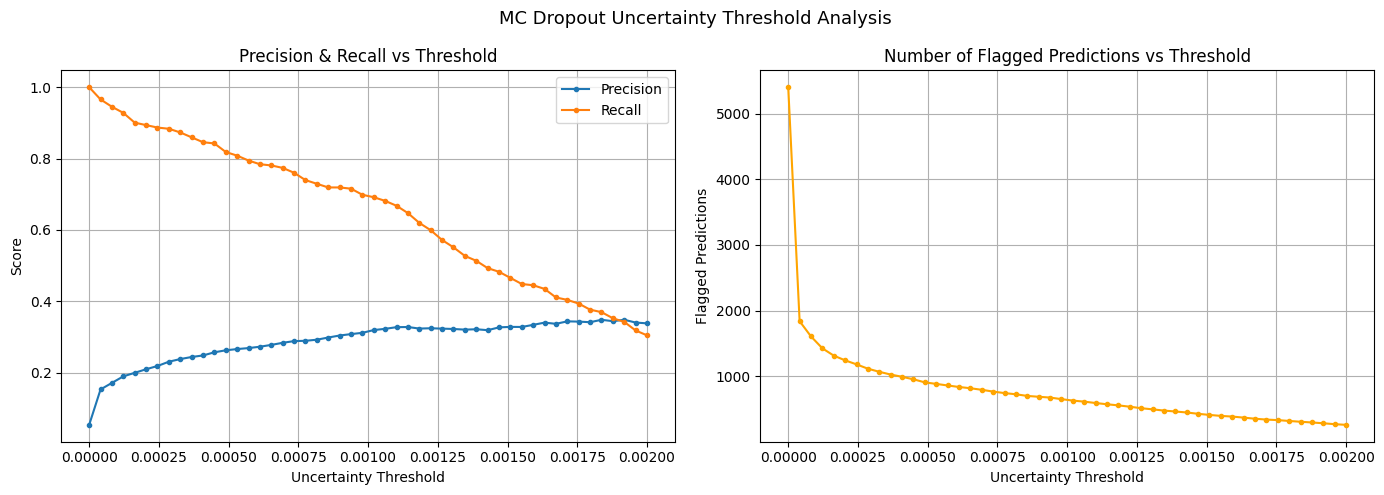


Best threshold:  0.001143
Precision:       0.3281
Recall:          0.6473
Flagged:         576 predictions


In [26]:
# Find optimal threshold to flag uncertain predictions
thresholds = np.linspace(0, 0.002, 50)

results_thresh = []
for thresh in thresholds:
    flagged      = all_uncertainty > thresh
    not_flagged  = ~flagged

    # Among flagged — how many are actually wrong?
    if flagged.sum() > 0:
        precision = wrong_mask[flagged].sum() / flagged.sum()
    else:
        precision = 0

    # How many wrong predictions did we catch?
    if wrong_mask.sum() > 0:
        recall = wrong_mask[flagged].sum() / wrong_mask.sum()
    else:
        recall = 0

    results_thresh.append({
        'threshold': thresh,
        'flagged':   flagged.sum(),
        'precision': precision,
        'recall':    recall
    })

# Plot
thresholds_arr = [r['threshold'] for r in results_thresh]
precisions     = [r['precision'] for r in results_thresh]
recalls        = [r['recall']    for r in results_thresh]
flagged_counts = [r['flagged']   for r in results_thresh]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds_arr, precisions, label='Precision', marker='o', markersize=3)
ax1.plot(thresholds_arr, recalls,    label='Recall',    marker='o', markersize=3)
ax1.set_xlabel('Uncertainty Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision & Recall vs Threshold')
ax1.legend()
ax1.grid(True)

ax2.plot(thresholds_arr, flagged_counts, color='orange', marker='o', markersize=3)
ax2.set_xlabel('Uncertainty Threshold')
ax2.set_ylabel('Flagged Predictions')
ax2.set_title('Number of Flagged Predictions vs Threshold')
ax2.grid(True)

plt.suptitle('MC Dropout Uncertainty Threshold Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# Find best threshold — highest precision with recall > 0.5
best = max(
    [r for r in results_thresh if r['recall'] > 0.5],
    key=lambda x: x['precision']
)
print(f"\nBest threshold:  {best['threshold']:.6f}")
print(f"Precision:       {best['precision']:.4f}")
print(f"Recall:          {best['recall']:.4f}")
print(f"Flagged:         {best['flagged']} predictions")

=== System Performance ===

Unflagged predictions: 4824
Unflagged accuracy:    0.9786

Flagged for review:    576
Flagged accuracy:      0.6719

Overall accuracy:      0.9459


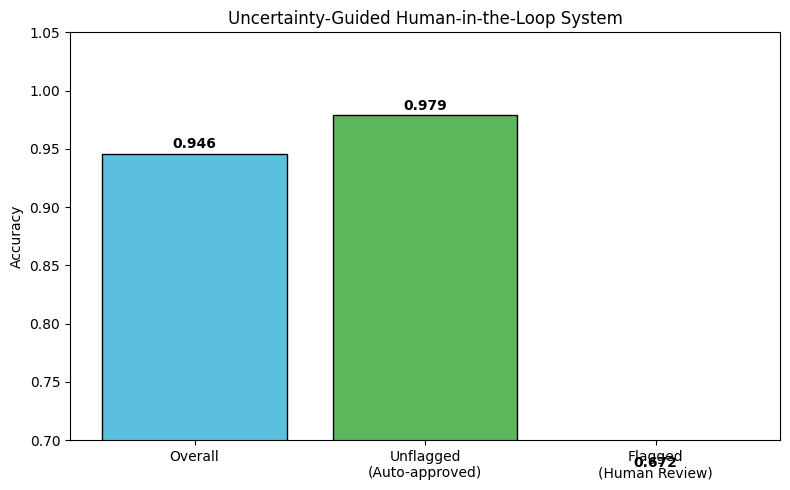

In [27]:
threshold = best['threshold']
flagged_mask   = all_uncertainty > threshold
unflagged_mask = ~flagged_mask

print("=== System Performance ===")
print(f"\nUnflagged predictions: {unflagged_mask.sum()}")
unflagged_acc = (all_pred_class[unflagged_mask] == all_labels_mc[unflagged_mask]).mean()
print(f"Unflagged accuracy:    {unflagged_acc:.4f}")

print(f"\nFlagged for review:    {flagged_mask.sum()}")
flagged_acc = (all_pred_class[flagged_mask] == all_labels_mc[flagged_mask]).mean()
print(f"Flagged accuracy:      {flagged_acc:.4f}")

print(f"\nOverall accuracy:      {(all_pred_class == all_labels_mc).mean():.4f}")

# Visualize
categories = ['Overall', 'Unflagged\n(Auto-approved)', 'Flagged\n(Human Review)']
accuracies = [
    (all_pred_class == all_labels_mc).mean(),
    unflagged_acc,
    flagged_acc
]
colors = ['#5bc0de', '#5cb85c', '#d9534f']

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, accuracies, color=colors, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc:.3f}',
             ha='center', fontweight='bold')
plt.ylim(0.7, 1.05)
plt.ylabel('Accuracy')
plt.title('Uncertainty-Guided Human-in-the-Loop System')
plt.tight_layout()
plt.show()